<a href="https://colab.research.google.com/github/alifarokhi066/ECG/blob/main/EEG_proces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Library**

In [ ]:
pip install numpy pandas scipy mne pywavelets scikit-learn tensorflow keras torch matplotlib seaborn jupyter openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling jupyter-client-6.1.12:
      Successfully uninstalled jupyter-client-6.1.12
  Attempting uninstall: ipyk

In [ ]:
import numpy as np
data = np.array([1, 2, 3])

In [ ]:
import pandas as pd
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})

In [ ]:
from scipy import signal
b, a = signal.butter(4, 0.1, 'low')  # طراحی فیلتر پایین‌گذر

In [ ]:
import mne
raw = mne.io.read_raw_edf('sample.edf', preload=True)

In [ ]:
import pywt
coeffs = pywt.wavedec(data, 'db4', level=4)

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X_train, y_train)

In [ ]:
import torch
import torch.nn as nn
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=100))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
import matplotlib.pyplot as plt
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [ ]:
import seaborn as sns
sns.heatmap(data.corr(), annot=True)

In [ ]:
from openpyxl import Workbook
wb = Workbook()
ws = wb.active
ws['A1'] = 'Hello'
wb.save('sample.xlsx')

## ***CSP***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# شبیه‌سازی سیگنال‌های دو کلاس EEG با واریانس‌های مختلف
np.random.seed(42)
t = np.linspace(0, 1, 500)  # محور زمان
class1_raw = 0.5 * np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(500)  # سیگنال کلاس 1
class2_raw = 0.3 * np.sin(2 * np.pi * 10 * t + np.pi / 4) + 0.1 * np.random.randn(500)  # سیگنال کلاس 2

# بعد از اعمال CSP (ایجاد تفاوت واریانس بین کلاس‌ها)
class1_csp = 2.0 * np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(500)  # تقویت واریانس کلاس 1
class2_csp = 0.2 * np.sin(2 * np.pi * 10 * t + np.pi / 4) + 0.1 * np.random.randn(500)  # کاهش واریانس کلاس 2

# رسم شکل‌ها
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# سیگنال‌های
axs[0, 0].plot(t, class1_raw, label='Class 1')
axs[0, 0].plot(t, class2_raw, label='Class 2')
axs[0, 0].set_title("Raw EEG Signals (Before CSP)")
axs[0, 0].legend()
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Amplitude")

# پراکندگی واریانس سیگنال‌های
axs[0, 1].scatter(class1_raw, class2_raw, alpha=0.5, label='Overlap Between Classes')
axs[0, 1].set_title("Variance Overlap (Before CSP)")
axs[0, 1].legend()
axs[0, 1].set_xlabel("Class 1 Amplitude")
axs[0, 1].set_ylabel("Class 2 Amplitude")

# سیگنال‌های بعد از اعمال CSP
axs[1, 0].plot(t, class1_csp, label='Class 1 (CSP)')
axs[1, 0].plot(t, class2_csp, label='Class 2 (CSP)')
axs[1, 0].set_title("EEG Signals (After CSP)")
axs[1, 0].legend()
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].set_ylabel("Amplitude")

# پراکندگی واریانس سیگنال‌های بعد از CSP
axs[1, 1].scatter(class1_csp, class2_csp, alpha=0.5, label='Separated Classes')
axs[1, 1].set_title("Variance Separation (After CSP)")
axs[1, 1].legend()
axs[1, 1].set_xlabel("Class 1 Amplitude")
axs[1, 1].set_ylabel("Class 2 Amplitude")

plt.tight_layout()
plt.show()


# *شبکه LSTM*

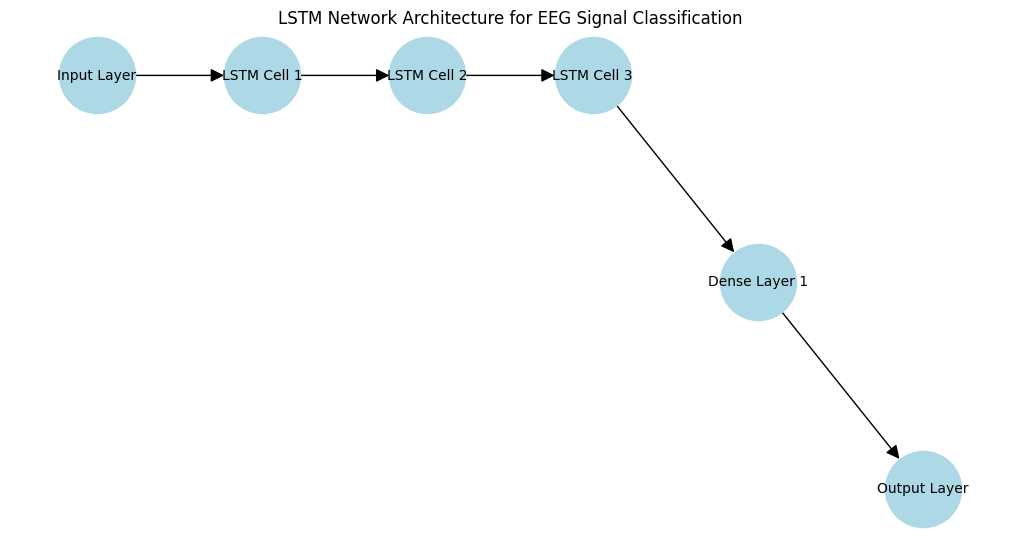

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# تعریف گره‌های شبکه LSTM
nodes = [
    "Input Layer", "LSTM Cell 1", "LSTM Cell 2", "LSTM Cell 3",
    "Dense Layer 1", "Output Layer"
]

# تعریف لبه‌های شبکه (ارتباط بین گره‌ها)
edges = [
    ("Input Layer", "LSTM Cell 1"),
    ("LSTM Cell 1", "LSTM Cell 2"),
    ("LSTM Cell 2", "LSTM Cell 3"),
    ("LSTM Cell 3", "Dense Layer 1"),
    ("Dense Layer 1", "Output Layer")
]

# ایجاد گراف
G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# موقعیت‌دهی گره‌ها برای نمایش
pos = {
    "Input Layer": (0, 2),
    "LSTM Cell 1": (1, 2),
    "LSTM Cell 2": (2, 2),
    "LSTM Cell 3": (3, 2),
    "Dense Layer 1": (4, 1),
    "Output Layer": (5, 0)
}

# رسم گراف
plt.figure(figsize=(10, 5))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', arrowsize=20, font_size=10)
plt.title("LSTM Network Architecture for EEG Signal Classification")
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.2574 - loss: 1.3936 - val_accuracy: 0.2700 - val_loss: 1.3829
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.2512 - loss: 1.3869 - val_accuracy: 0.2150 - val_loss: 1.3890
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2581 - loss: 1.3861 - val_accuracy: 0.2600 - val_loss: 1.3862
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2652 - loss: 1.3848 - val_accuracy: 0.2600 - val_loss: 1.3840
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.2975 - loss: 1.3804 - val_accuracy: 0.2450 - val_loss: 1.3905
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2557 - loss: 1.3873 - val_accuracy: 0.2450 - val_loss: 1.3875
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.2892 - loss: 1.3824 - val_accuracy: 0.2750 - val_loss: 1.3873
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.2666 - loss: 1.3805 - val_accuracy: 0.2400 - 

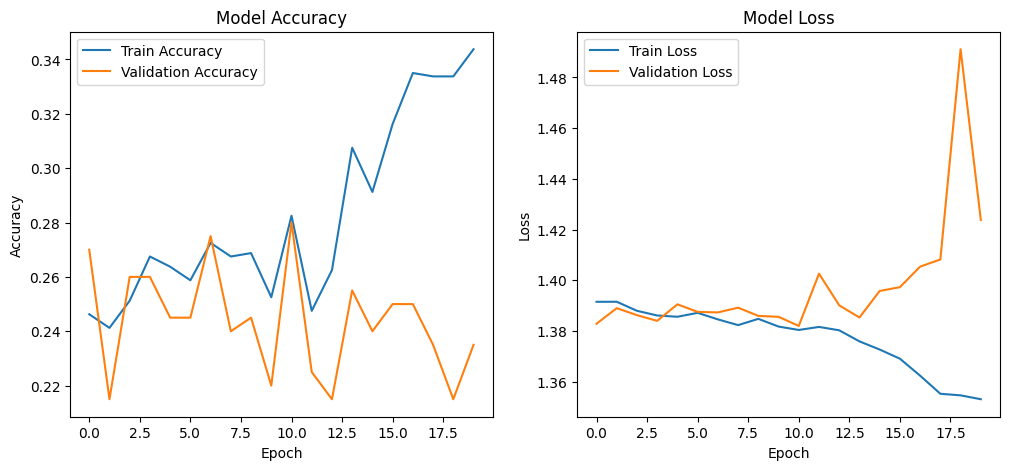

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Step 1: Generate synthetic EEG-like data
num_samples = 1000
num_timesteps = 50
num_features = 8
num_classes = 4

np.random.seed(42)
X = np.random.rand(num_samples, num_timesteps, num_features)
y = np.random.randint(0, num_classes, size=(num_samples,))
y = to_categorical(y, num_classes)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Build LSTM + DNN model
model = Sequential()
model.add(LSTM(64, input_shape=(num_timesteps, num_features), return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 3: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 4: Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# ***Test & Train***

In [ ]:
from sklearn.model_selection import train_test_split

# فرض شده X داده‌های ویژگی‌ها و y برچسب‌ها هستند
X = [[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]]
y = [0, 1, 0, 1, 0]

# تقسیم داده‌ها به آموزش و آزمون ( 80% آموزش و 20% آزمون)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("داده‌های آموزش (X_train):", X_train)
print("داده‌های آزمون (X_test):", X_test)
print("برچسب‌های آموزش (y_train):", y_train)
print("برچسب‌های آزمون (y_test):", y_test)

# ***DNN***

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report

# فرض کنید X ویژگی‌های استخراج شده و y برچسب‌های مربوط به احساسات هستند
# X باید به شکل (نمونه‌ها، ویژگی‌ها) باشد و y باید شامل اعداد صحیح به‌عنوان برچسب کلاس‌ها باشد

# تقسیم داده‌ها به 80% آموزش و 20% تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# اگر y به‌صورت عددی است، باید به دسته‌های one-hot تبدیل شود
num_classes = len(np.unique(y))  # تعداد کلاس‌های احساسات
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# ساخت مدل DNN
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))  # لایه ورودی با 128 نورون
model.add(Dropout(0.5))  # لایه Dropout برای جلوگیری از overfitting
model.add(Dense(64, activation='relu'))  # لایه پنهان با 64 نورون
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))  # لایه خروجی با تابع Softmax

# کامپایل کردن مدل
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# آموزش مدل
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# ارزیابی مدل روی داده‌های تست
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# محاسبه دقت و گزارش عملکرد
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Test Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))


NameError: name 'X' is not defined

# ***Accuracy***

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.2811 - loss: 1.5922 - val_accuracy: 0.3812 - val_loss: 1.1462
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3375 - loss: 1.3218 - val_accuracy: 0.3812 - val_loss: 1.1304
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3682 - loss: 1.2145 - val_accuracy: 0.3750 - val_loss: 1.1241
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4036 - loss: 1.1583 - val_accuracy: 0.3562 - val_loss: 1.1160
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3567 - loss: 1.2036 - val_accuracy: 0.3625 - val_loss: 1.1086
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3720 - loss: 1.2207 - val_accuracy: 0.3688 - val_loss: 1.1048
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3934 - loss: 1.1300 - val_accuracy: 0.3625 - val_loss: 1.1030
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4267 - loss: 1.0852 - val_accuracy: 0.3938 - v

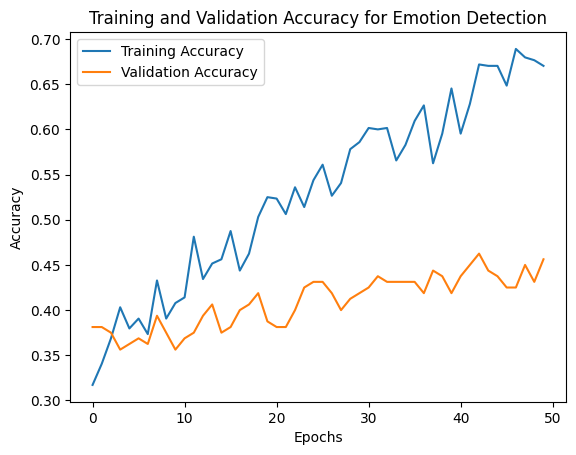

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import History

# تولید داده‌های شبیه‌سازی شده EEG
np.random.seed(42)
n_samples = 1000  # تعداد نمونه‌ها
n_features = 64   # تعداد ویژگی‌ها (کانال‌های EEG)

X = np.random.rand(n_samples, n_features)  # داده‌های EEG
y = np.random.randint(0, 3, n_samples)  # برچسب‌های احساسات (0: مثبت, 1: منفی, 2: خنثی)

# تقسیم داده‌ها به آموزش و آزمون
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# نرمال‌سازی داده‌ها
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# تعریف مدل ساده‌تر (FFNN)
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(n_features,)))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))  # 3 کلاس احساسات

# کامپایل مدل
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# آموزش مدل و ذخیره تاریخچه‌ی دقت
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# رسم نمودار دقت
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Emotion Detection')
plt.legend()
plt.show()

# ***Confusion Matrix***

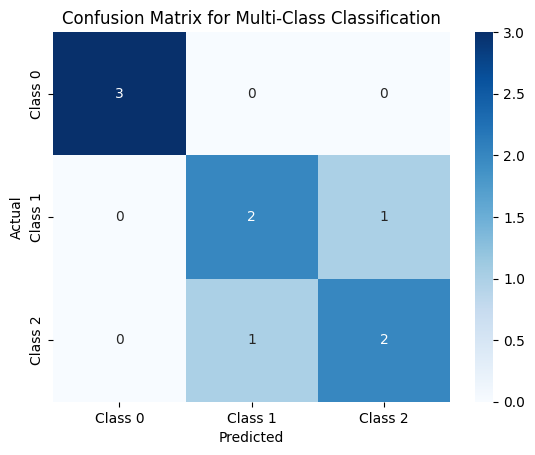

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# فرض کنید y_true برچسب‌های واقعی و y_pred پیش‌بینی‌های مدل هستند
y_true = [0, 1, 2, 0, 1, 2, 0, 1, 2]  # برچسب‌های واقعی (3 کلاس)
y_pred = [0, 1, 2, 0, 1, 1, 0, 2, 2]  # پیش‌بینی‌های مدل

# محاسبه ماتریس خطا
cm = confusion_matrix(y_true, y_pred)

# رسم ماتریس خطا
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Multi-Class Classification')
plt.show()

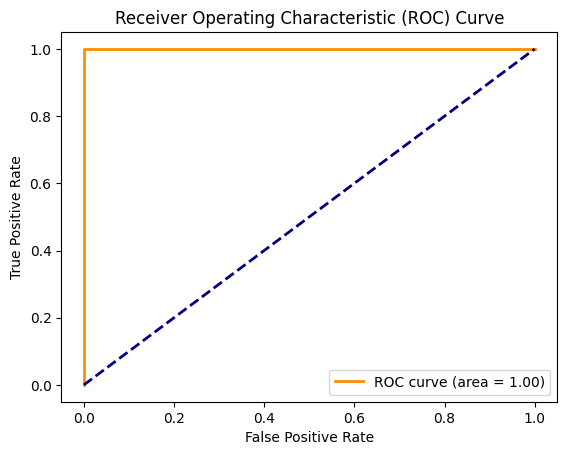

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# فرض کنید y_true برچسب‌های واقعی و y_pred_prob احتمال‌های پیش‌بینی مدل هستند
y_true = [0, 1, 1, 0, 1, 0, 1, 0, 0, 1]  # برچسب‌های واقعی
y_pred_prob = [0.1, 0.9, 0.8, 0.3, 0.7, 0.2, 0.85, 0.4, 0.6, 0.95]  # احتمال‌های پیش‌بینی

# محاسبه منحنی ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# رسم منحنی ROC
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# ***F1-Score***

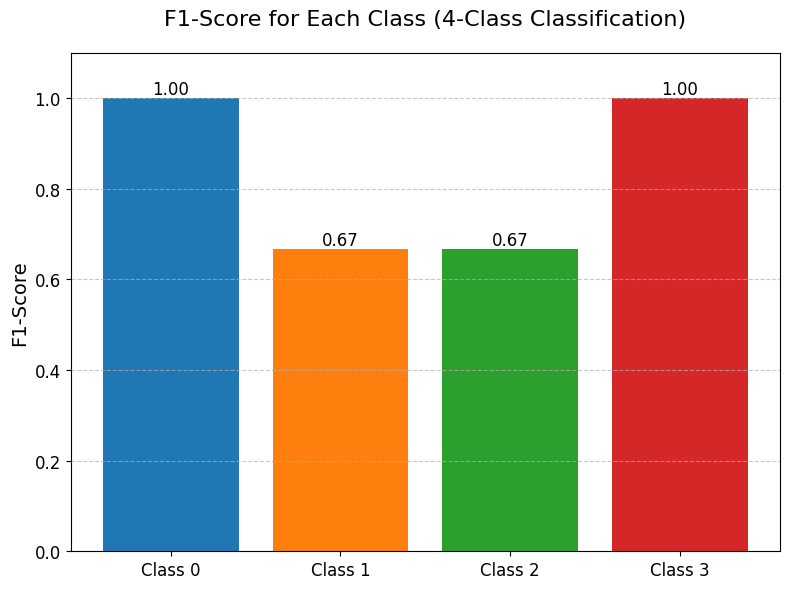

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# فرض  y_true برچسب‌های واقعی و y_pred پیش‌بینی‌های مدل هستند
y_true = [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]  # برچسب‌های واقعی (4 کلاس)
y_pred = [0, 1, 2, 3, 0, 1, 1, 3, 0, 2, 2, 3]  # پیش‌بینی‌های مدل

# محاسبه F1-Score برای هر کلاس
f1_scores = f1_score(y_true, y_pred, average=None)  # average=None برای محاسبه F1-Score هر کلاس

# نام کلاس‌ها
classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

# رنگ‌های زیبا برای هر کلاس
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# رسم نمودار F1-Score برای هر کلاس
plt.figure(figsize=(8, 6))  # تنظیم اندازه نمودار
bars = plt.bar(classes, f1_scores, color=colors)

# افزودن اعداد روی میله‌ها
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
             ha='center', va='bottom', fontsize=12)

# تنظیمات بصری
plt.ylabel('F1-Score', fontsize=14)
plt.ylim(0, 1.1)  # محدوده‌ی محور Y بین ۰ تا ۱.۱
plt.title('F1-Score for Each Class (4-Class Classification)', fontsize=16, pad=20)
plt.xticks(fontsize=12)  # تنظیم فونت‌سایز برچسب‌های محور X
plt.yticks(fontsize=12)  # تنظیم فونت‌سایز برچسب‌های محور Y
plt.grid(axis='y', linestyle='--', alpha=0.7)  # افزودن خطوط شبکه‌ای به محور Y

# نمایش نمودار
plt.tight_layout()  # جلوگیری از بریده‌شدن برچسب‌ها
plt.show()